# Digital Waveguide Mesh Prototype

このノートブックは、`research/scripts/` に追加した最小 DWM 骨格を呼び出し、
**直管のインパルス応答** と **簡易母音形状** の実験を始めるための入口です。

最初の目的は次の 3 点です。

- 2D 矩形格子で最小 DWM 実験が動くことを確認する
- 直管のインパルス応答と主要ピークを観察する
- 後で母音プリセット比較へ拡張しやすい形に整える


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

cwd = Path.cwd().resolve()
research_root_candidates = [cwd, cwd.parent]
research_root = next(
    candidate
    for candidate in research_root_candidates
    if (candidate / "scripts").exists() and (candidate / "notebooks").exists()
)

if str(research_root) not in sys.path:
    sys.path.insert(0, str(research_root))

from scripts.dwm_analysis import compute_spectrogram, compute_spectrum, find_major_peaks, save_wav
from scripts.dwm_config import make_default_config
from scripts.dwm_mesh import build_rect_mesh, summarize_mesh
from scripts.dwm_shapes import make_uniform_tube_shape, make_vowel_shape
from scripts.dwm_solver import run_dwm
from scripts.dwm_sources import make_impulse, make_pulse_train, make_simple_glottal_source


## 実験設定

まずは直管の最小実験を既定値で回します。
必要に応じて `duration_sec`, `grid_step_m`, `source_kind` などを変更してください。


In [2]:
config = make_default_config()
config["duration_sec"] = 0.12
config["grid_step_m"] = 0.004

shape_kind = "uniform_tube"
source_kind = "impulse"

tube_length_m = 0.17
tube_width_m = 0.03

sample_rate = config["sample_rate"]
n_samples = int(sample_rate * config["duration_sec"])

config


{'sample_rate': 44100,
 'duration_sec': 0.12,
 'sound_speed': 343.0,
 'grid_step_m': 0.004,
 'f0': 120.0,
 'loss': 0.999,
 'wall_reflection': 0.995,
 'open_reflection': -0.92,
 'source_reflection': 0.85,
 'lip_probe': 'lip',
 'courant_factor': 0.95,
 'output_mode': 'radiated',
 'radiation_cutoff_hz': 1200.0,
 'radiation_gain': 1.0}

## 形状とメッシュの生成

`uniform_tube` では直管、`vowel_a` などでは簡易母音形状を使えます。


In [3]:
if shape_kind == "uniform_tube":
    shape = make_uniform_tube_shape(length_m=tube_length_m, width_m=tube_width_m)
elif shape_kind.startswith("vowel_"):
    shape = make_vowel_shape(shape_kind.split("_", 1)[1], length_m=tube_length_m)
else:
    raise ValueError(f"Unsupported shape_kind: {shape_kind}")

mesh = build_rect_mesh(shape, dx=config["grid_step_m"])
mesh_summary = summarize_mesh(mesh)
mesh_summary


{'grid_shape': (10, 46),
 'active_cells': 294,
 'glottal_cells': 7,
 'lip_cells': 7,
 'dx': 0.004,
 'label': 'uniform_tube'}

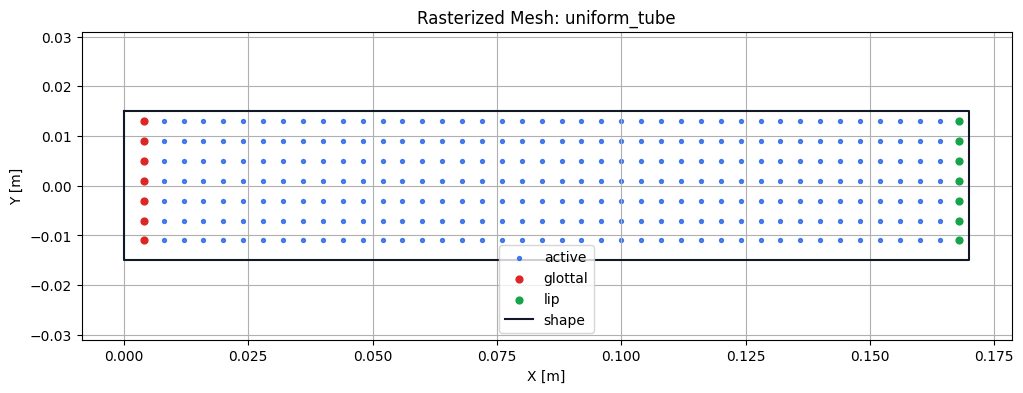

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title(f"Rasterized Mesh: {shape['label']}")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

active = mesh["active"]
xs = mesh["xs"]
ys = mesh["ys"]

ax.scatter(xs[active], ys[active], s=8, c="#2563eb", alpha=0.8, label="active")
ax.scatter(xs[mesh['glottal_mask']], ys[mesh['glottal_mask']], s=24, c="#dc2626", label="glottal")
ax.scatter(xs[mesh['lip_mask']], ys[mesh['lip_mask']], s=24, c="#16a34a", label="lip")

polygon = np.asarray(shape["polygon"])
polygon_closed = np.vstack([polygon, polygon[0]])
ax.plot(polygon_closed[:, 0], polygon_closed[:, 1], color="#111827", linewidth=1.5, label="shape")
ax.axis("equal")
ax.legend()
plt.show()


## 音源の生成

最初はインパルス応答を見るのが主目的なので、既定では `impulse` を使います。
必要なら `pulse_train` や `simple_glottal` に切り替えられます。


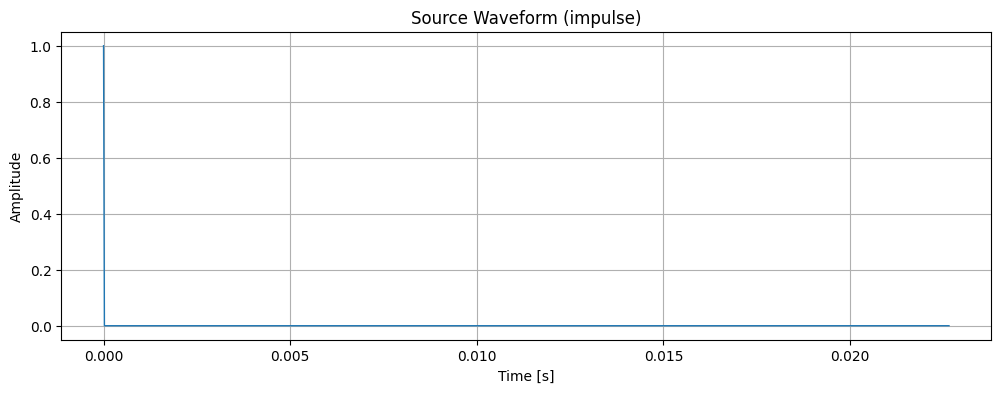

In [5]:
if source_kind == "impulse":
    source = make_impulse(n_samples, amplitude=1.0)
elif source_kind == "pulse_train":
    source = make_pulse_train(n_samples, fs=sample_rate, f0=config["f0"], amplitude=1.0)
elif source_kind == "simple_glottal":
    source = make_simple_glottal_source(n_samples, fs=sample_rate, f0=config["f0"], amplitude=1.0)
else:
    raise ValueError(f"Unsupported source_kind: {source_kind}")

time_axis = np.arange(n_samples) / sample_rate

fig, ax = plt.subplots()
ax.plot(time_axis[: min(1000, n_samples)], source[: min(1000, n_samples)], linewidth=1.0)
ax.set_title(f"Source Waveform ({source_kind})")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
plt.show()


## DWM 実行

口端 (`probe="lip"`) で観測した波形を取得します。


In [6]:
result = run_dwm(mesh, source, config, probe="lip")
output = result["output"]

result["meta"]


{'num_samples': 5292,
 'probe': 'lip',
 'active_cells': 294,
 'internal_dt_sec': 7.833836059792653e-06,
 'internal_fs_hz': 127651.38207736098,
 'substeps_per_sample': 3,
 'output_mode': 'radiated',
 'radiation_cutoff_hz': 1200.0}

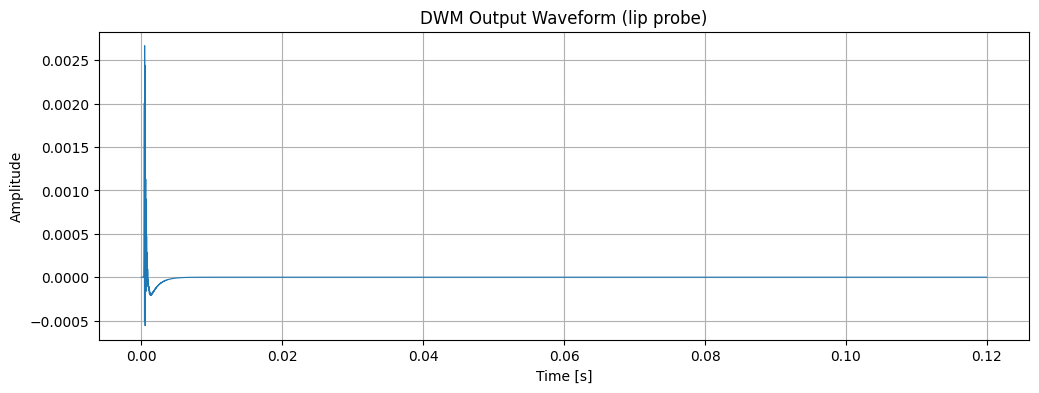

14

In [7]:
fig, ax = plt.subplots()
ax.plot(time_axis, output, linewidth=0.8)
ax.set_title("DWM Output Waveform (lip probe)")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
plt.show()

first_nonzero = next((i for i, value in enumerate(output) if abs(value) > 1e-12), None)
first_nonzero


## スペクトル観察

ここでは厳密なフォルマント推定ではなく、まずは主要ピークの観察に留めます。


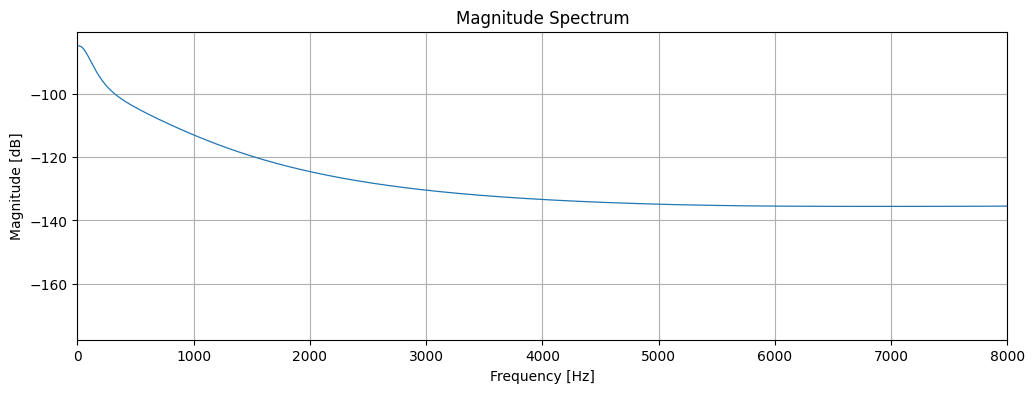

array([10258.33333333, 11675.        , 14175.        , 21891.66666667])

In [8]:
frequencies, magnitude_db = compute_spectrum(output, sample_rate)
major_peaks = find_major_peaks(output, sample_rate, n_peaks=5)

fig, ax = plt.subplots()
ax.plot(frequencies, magnitude_db, linewidth=0.9)
ax.set_title("Magnitude Spectrum")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Magnitude [dB]")
ax.set_xlim(0, 8000)

for peak_hz in major_peaks:
    ax.axvline(peak_hz, color="#dc2626", linestyle="--", linewidth=1.0)

plt.show()
major_peaks


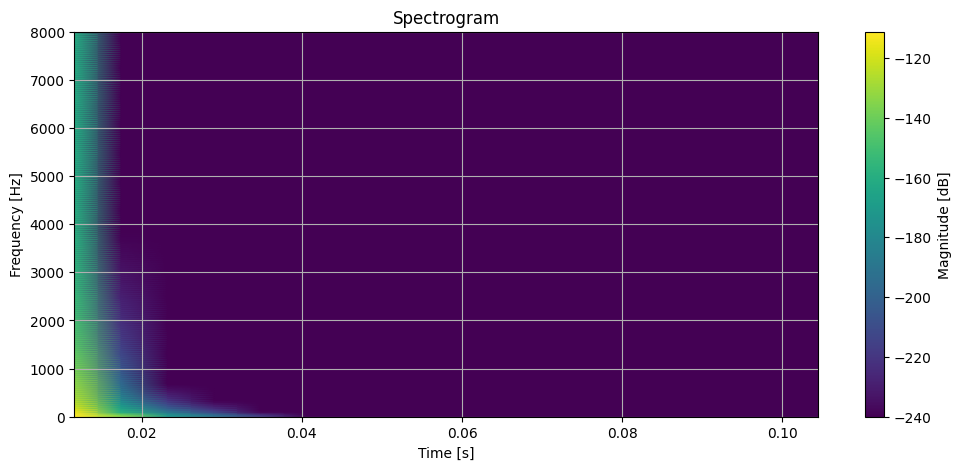

In [9]:
frequencies_sg, times_sg, spectrogram_db = compute_spectrogram(output, sample_rate)

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.pcolormesh(times_sg, frequencies_sg, spectrogram_db, shading="gouraud")
ax.set_title("Spectrogram")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Frequency [Hz]")
ax.set_ylim(0, min(sample_rate / 2, 8000))
fig.colorbar(image, ax=ax, label="Magnitude [dB]")
plt.show()


## 再生と保存

WAV を `research/data/generated/` に保存します。


In [10]:
generated_dir = research_root / "data" / "generated"
output_name = f"dwm_{shape['label']}_{source_kind}.wav"
output_path = generated_dir / output_name

save_wav(output_path, output, sample_rate)
output_path


PosixPath('/Users/dolphilia/github/voice-simulator/research/data/generated/dwm_uniform_tube_impulse.wav')

In [11]:
display(Audio(output, rate=sample_rate))


## `vowel_a` / `vowel_i` 比較

同じ設定・同じ音源で `vowel_a` と `vowel_i` を生成し、波形とスペクトルの差を確認します。


In [12]:
compare_vowels = ["a", "i"]
compare_results = {}

for vowel in compare_vowels:
    compare_shape = make_vowel_shape(vowel, length_m=tube_length_m)
    compare_mesh = build_rect_mesh(compare_shape, dx=config["grid_step_m"])
    compare_result = run_dwm(compare_mesh, source, config, probe="lip")
    compare_output = compare_result["output"]
    compare_freqs, compare_mag_db = compute_spectrum(compare_output, sample_rate)
    compare_peaks = find_major_peaks(compare_output, sample_rate, n_peaks=5)
    compare_results[vowel] = {
        "shape": compare_shape,
        "mesh": compare_mesh,
        "result": compare_result,
        "output": compare_output,
        "frequencies": compare_freqs,
        "magnitude_db": compare_mag_db,
        "peaks": compare_peaks,
    }

{
    vowel: {
        "mesh": summarize_mesh(data["mesh"]),
        "num_samples": data["result"]["meta"]["num_samples"],
        "peaks_hz": [float(v) for v in data["peaks"]],
    }
    for vowel, data in compare_results.items()
}


{'a': {'mesh': {'grid_shape': (12, 46),
   'active_cells': 308,
   'glottal_cells': 9,
   'lip_cells': 6,
   'dx': 0.004,
   'label': 'vowel_a'},
  'num_samples': 5292,
  'peaks_hz': [10491.666666666668, 11858.333333333334, 14425.000000000002]},
 'i': {'mesh': {'grid_shape': (10, 46),
   'active_cells': 210,
   'glottal_cells': 7,
   'lip_cells': 3,
   'dx': 0.004,
   'label': 'vowel_i'},
  'num_samples': 5292,
  'peaks_hz': []}}

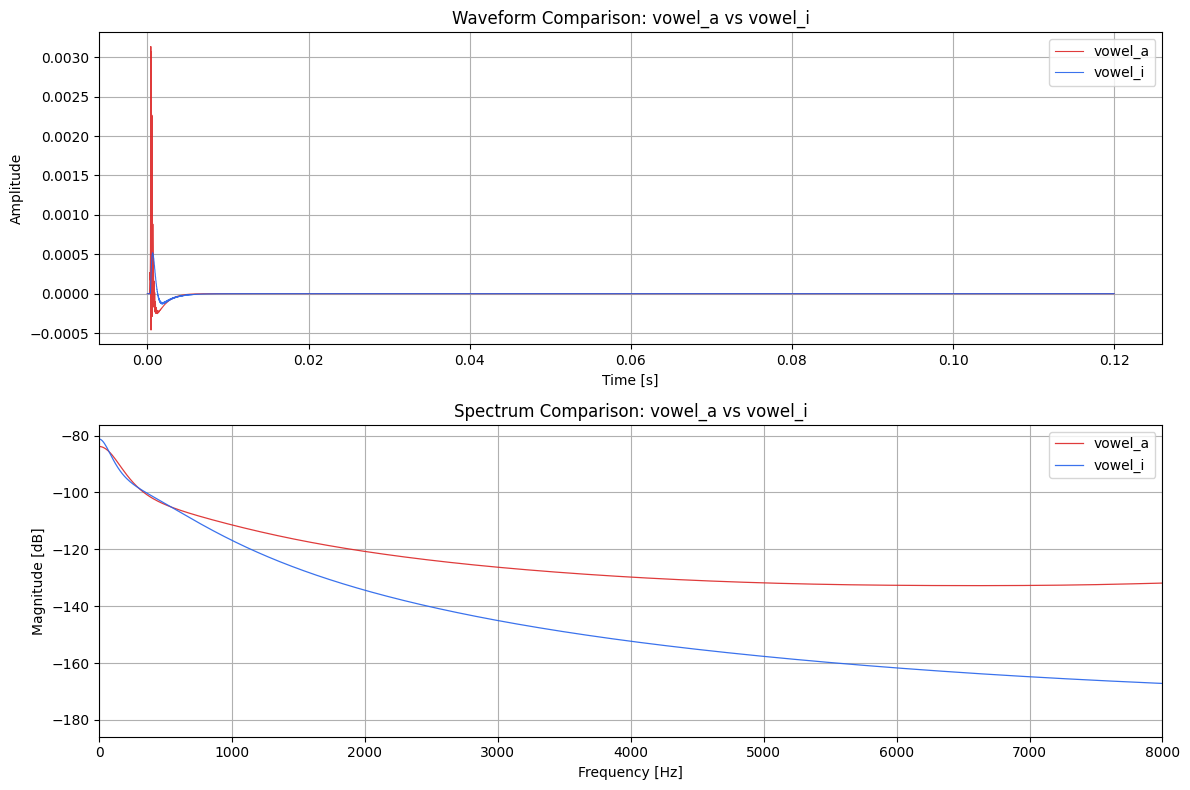

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for vowel, color in [("a", "#dc2626"), ("i", "#2563eb")]:
    data = compare_results[vowel]
    axes[0].plot(time_axis, data["output"], linewidth=0.8, label=f"vowel_{vowel}", color=color, alpha=0.9)
    axes[1].plot(data["frequencies"], data["magnitude_db"], linewidth=0.9, label=f"vowel_{vowel}", color=color, alpha=0.9)
    for peak_hz in data["peaks"]:
        axes[1].axvline(peak_hz, color=color, linestyle="--", linewidth=0.8, alpha=0.6)

axes[0].set_title("Waveform Comparison: vowel_a vs vowel_i")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].set_title("Spectrum Comparison: vowel_a vs vowel_i")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude [dB]")
axes[1].set_xlim(0, 8000)
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
for vowel in compare_vowels:
    out_path = research_root / "data" / "generated" / f"dwm_vowel_{vowel}_{source_kind}.wav"
    save_wav(out_path, compare_results[vowel]["output"], sample_rate)
    print(vowel, out_path)


a /Users/dolphilia/github/voice-simulator/research/data/generated/dwm_vowel_a_impulse.wav
i /Users/dolphilia/github/voice-simulator/research/data/generated/dwm_vowel_i_impulse.wav


## `simple_glottal` 励振での母音比較

インパルス応答だけでなく、簡易グロッタル波を使った持続励振でも `vowel_a` と `vowel_i` を比較します。


In [15]:
glottal_source = make_simple_glottal_source(n_samples, fs=sample_rate, f0=config["f0"], amplitude=1.0)
glottal_compare = {}

for vowel in compare_vowels:
    compare_shape = make_vowel_shape(vowel, length_m=tube_length_m)
    compare_mesh = build_rect_mesh(compare_shape, dx=config["grid_step_m"])
    compare_result = run_dwm(compare_mesh, glottal_source, config, probe="lip")
    compare_output = compare_result["output"]
    compare_freqs, compare_mag_db = compute_spectrum(compare_output, sample_rate)
    compare_peaks = find_major_peaks(compare_output, sample_rate, n_peaks=5)
    glottal_compare[vowel] = {
        "output": compare_output,
        "frequencies": compare_freqs,
        "magnitude_db": compare_mag_db,
        "peaks": compare_peaks,
    }

{vowel: [float(v) for v in data["peaks"]] for vowel, data in glottal_compare.items()}


{'a': [483.33333333333337,
  600.0,
  716.6666666666667,
  841.6666666666667,
  1316.6666666666667],
 'i': [116.66666666666667,
  358.33333333333337,
  483.33333333333337,
  600.0,
  716.6666666666667]}

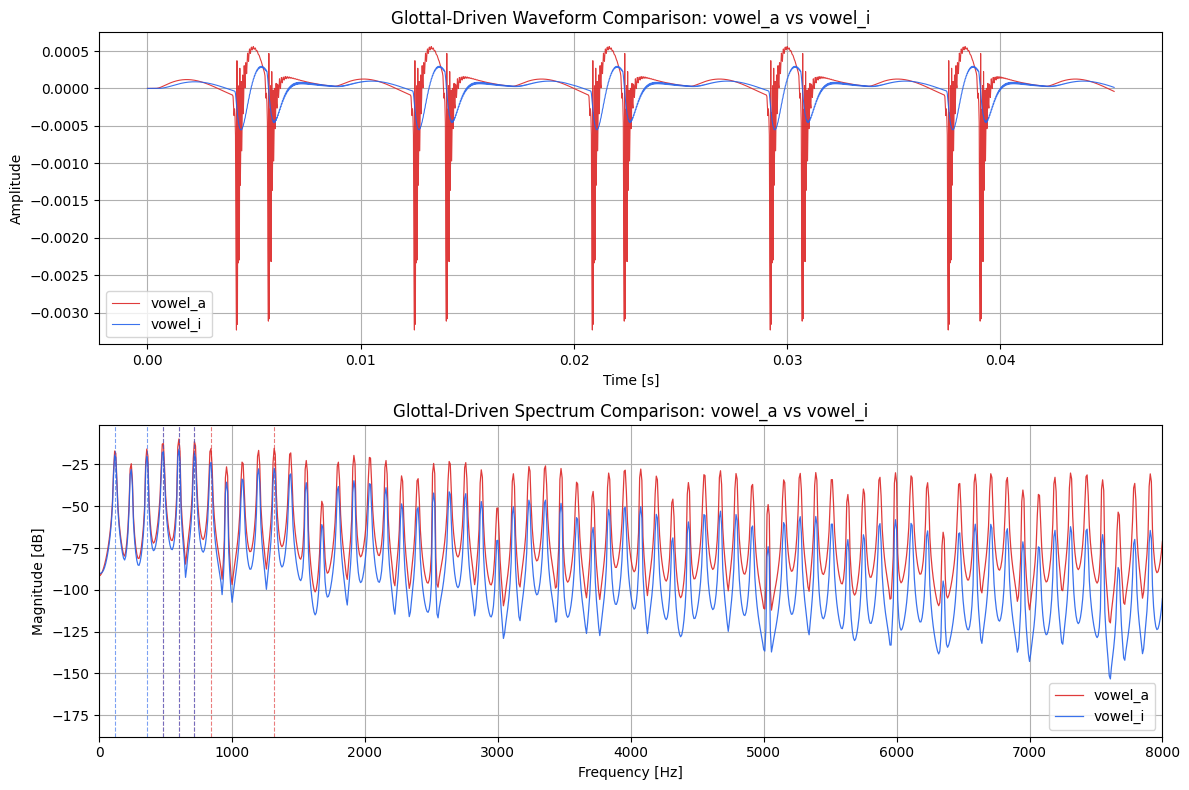

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for vowel, color in [("a", "#dc2626"), ("i", "#2563eb")]:
    data = glottal_compare[vowel]
    axes[0].plot(time_axis[:2000], data["output"][:2000], linewidth=0.8, label=f"vowel_{vowel}", color=color, alpha=0.9)
    axes[1].plot(data["frequencies"], data["magnitude_db"], linewidth=0.9, label=f"vowel_{vowel}", color=color, alpha=0.9)
    for peak_hz in data["peaks"]:
        axes[1].axvline(peak_hz, color=color, linestyle="--", linewidth=0.8, alpha=0.6)

axes[0].set_title("Glottal-Driven Waveform Comparison: vowel_a vs vowel_i")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].set_title("Glottal-Driven Spectrum Comparison: vowel_a vs vowel_i")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude [dB]")
axes[1].set_xlim(0, 8000)
axes[1].legend()

plt.tight_layout()
plt.show()


## `dx` と口端反射の試行

ピークがまだ高域寄りなので、まずは `dx` と `open_reflection` を変えたときに応答がどう変わるかを小さく確認します。
ここでは直管を対象に、比較のための最小スイープだけ行います。


In [17]:
sweep_cases = [
    {"name": "baseline", "grid_step_m": 0.004, "open_reflection": -0.92},
    {"name": "finer_grid", "grid_step_m": 0.0025, "open_reflection": -0.92},
    {"name": "softer_radiation", "grid_step_m": 0.004, "open_reflection": -0.70},
]

sweep_results = {}
for case in sweep_cases:
    sweep_config = dict(config)
    sweep_config["grid_step_m"] = case["grid_step_m"]
    sweep_config["open_reflection"] = case["open_reflection"]
    sweep_shape = make_uniform_tube_shape(length_m=tube_length_m, width_m=tube_width_m)
    sweep_mesh = build_rect_mesh(sweep_shape, dx=sweep_config["grid_step_m"])
    sweep_result = run_dwm(sweep_mesh, source, sweep_config, probe="lip")
    sweep_output = sweep_result["output"]
    sweep_freqs, sweep_mag = compute_spectrum(sweep_output, sample_rate)
    sweep_peaks = find_major_peaks(sweep_output, sample_rate, n_peaks=5)
    sweep_results[case["name"]] = {
        "config": sweep_config,
        "mesh": summarize_mesh(sweep_mesh),
        "output": sweep_output,
        "frequencies": sweep_freqs,
        "magnitude_db": sweep_mag,
        "peaks": sweep_peaks,
    }

{name: {"mesh": data["mesh"], "peaks_hz": [float(v) for v in data["peaks"]]} for name, data in sweep_results.items()}


{'baseline': {'mesh': {'grid_shape': (10, 46),
   'active_cells': 294,
   'glottal_cells': 7,
   'lip_cells': 7,
   'dx': 0.004,
   'label': 'uniform_tube'},
  'peaks_hz': [10258.333333333334,
   11675.0,
   14175.000000000002,
   21891.666666666668]},
 'finer_grid': {'mesh': {'grid_shape': (15, 71),
   'active_cells': 737,
   'glottal_cells': 11,
   'lip_cells': 11,
   'dx': 0.0025,
   'label': 'uniform_tube'},
  'peaks_hz': [6441.666666666667,
   7000.000000000001,
   9075.0,
   10325.0,
   11200.0]},
 'softer_radiation': {'mesh': {'grid_shape': (10, 46),
   'active_cells': 294,
   'glottal_cells': 7,
   'lip_cells': 7,
   'dx': 0.004,
   'label': 'uniform_tube'},
  'peaks_hz': [10250.0, 11675.0, 14191.666666666668, 21900.0]}}

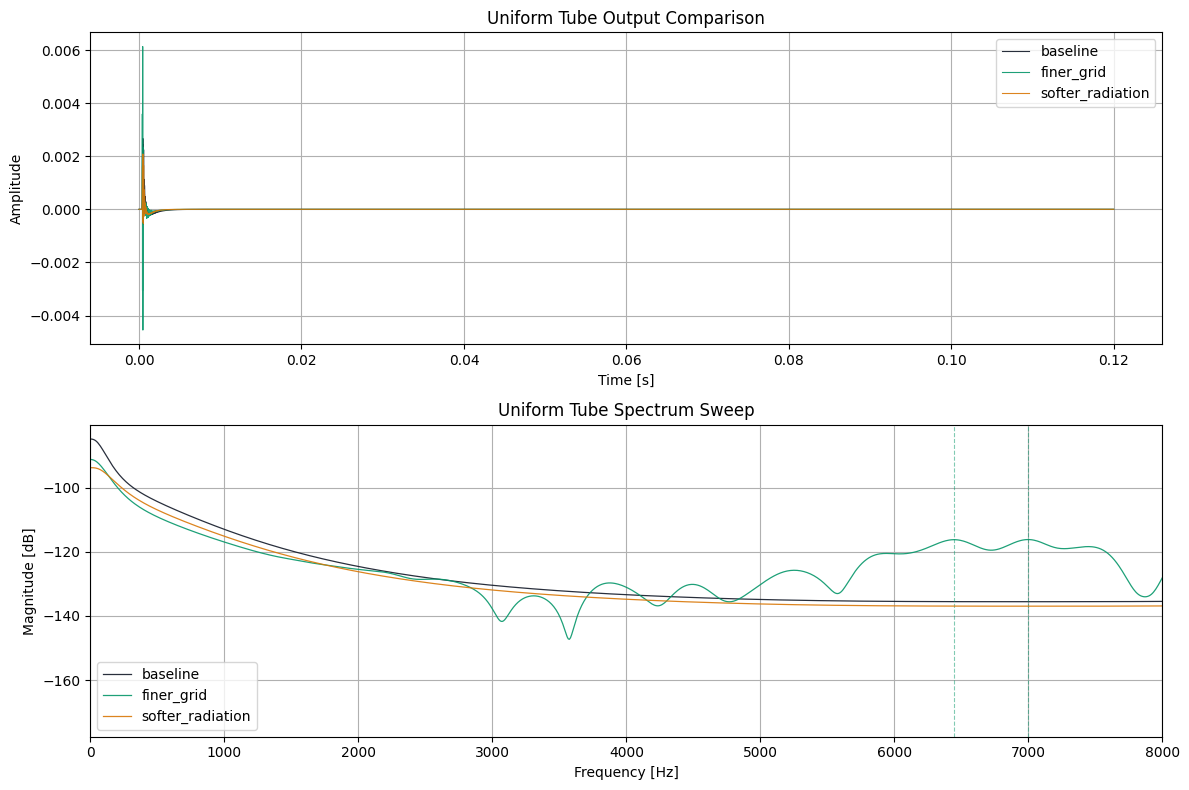

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
colors = {"baseline": "#111827", "finer_grid": "#059669", "softer_radiation": "#d97706"}

for name, data in sweep_results.items():
    color = colors[name]
    axes[0].plot(time_axis, data["output"], linewidth=0.8, label=name, color=color, alpha=0.9)
    axes[1].plot(data["frequencies"], data["magnitude_db"], linewidth=0.9, label=name, color=color, alpha=0.9)
    for peak_hz in data["peaks"]:
        axes[1].axvline(peak_hz, color=color, linestyle="--", linewidth=0.8, alpha=0.5)

axes[0].set_title("Uniform Tube Output Comparison")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].set_title("Uniform Tube Spectrum Sweep")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude [dB]")
axes[1].set_xlim(0, 8000)
axes[1].legend()

plt.tight_layout()
plt.show()


## 観測量の比較: `pressure` / `flow` / `radiated`

同じ形状・同じ音源で、口端観測量を `pressure`, `flow`, `radiated` に切り替えて比較します。
まずは直管を対象に、どの観測量が主出力として扱いやすいかを見ます。


In [19]:
output_modes = ["pressure", "flow", "radiated"]
mode_results = {}

for mode in output_modes:
    mode_config = dict(config)
    mode_config["output_mode"] = mode
    mode_shape = make_uniform_tube_shape(length_m=tube_length_m, width_m=tube_width_m)
    mode_mesh = build_rect_mesh(mode_shape, dx=mode_config["grid_step_m"])
    mode_result = run_dwm(mode_mesh, glottal_source, mode_config, probe="lip")
    mode_output = mode_result["output"]
    mode_freqs, mode_mag_db = compute_spectrum(mode_output, sample_rate)
    mode_peaks = find_major_peaks(mode_output, sample_rate, n_peaks=5)
    mode_results[mode] = {
        "result": mode_result,
        "output": mode_output,
        "frequencies": mode_freqs,
        "magnitude_db": mode_mag_db,
        "peaks": mode_peaks,
    }

{mode: {"meta": data["result"]["meta"], "peaks_hz": [float(v) for v in data["peaks"]]} for mode, data in mode_results.items()}


{'pressure': {'meta': {'num_samples': 5292,
   'probe': 'lip',
   'active_cells': 294,
   'internal_dt_sec': 7.833836059792653e-06,
   'internal_fs_hz': 127651.38207736098,
   'substeps_per_sample': 3,
   'output_mode': 'pressure',
   'radiation_cutoff_hz': 1200.0},
  'peaks_hz': [116.66666666666667,
   17975.0,
   18691.666666666668,
   19416.666666666668,
   20733.333333333336]},
 'flow': {'meta': {'num_samples': 5292,
   'probe': 'lip',
   'active_cells': 294,
   'internal_dt_sec': 7.833836059792653e-06,
   'internal_fs_hz': 127651.38207736098,
   'substeps_per_sample': 3,
   'output_mode': 'flow',
   'radiation_cutoff_hz': 1200.0},
  'peaks_hz': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 'radiated': {'meta': {'num_samples': 5292,
   'probe': 'lip',
   'active_cells': 294,
   'internal_dt_sec': 7.833836059792653e-06,
   'internal_fs_hz': 127651.38207736098,
   'substeps_per_sample': 3,
   'output_mode': 'radiated',
   'radia

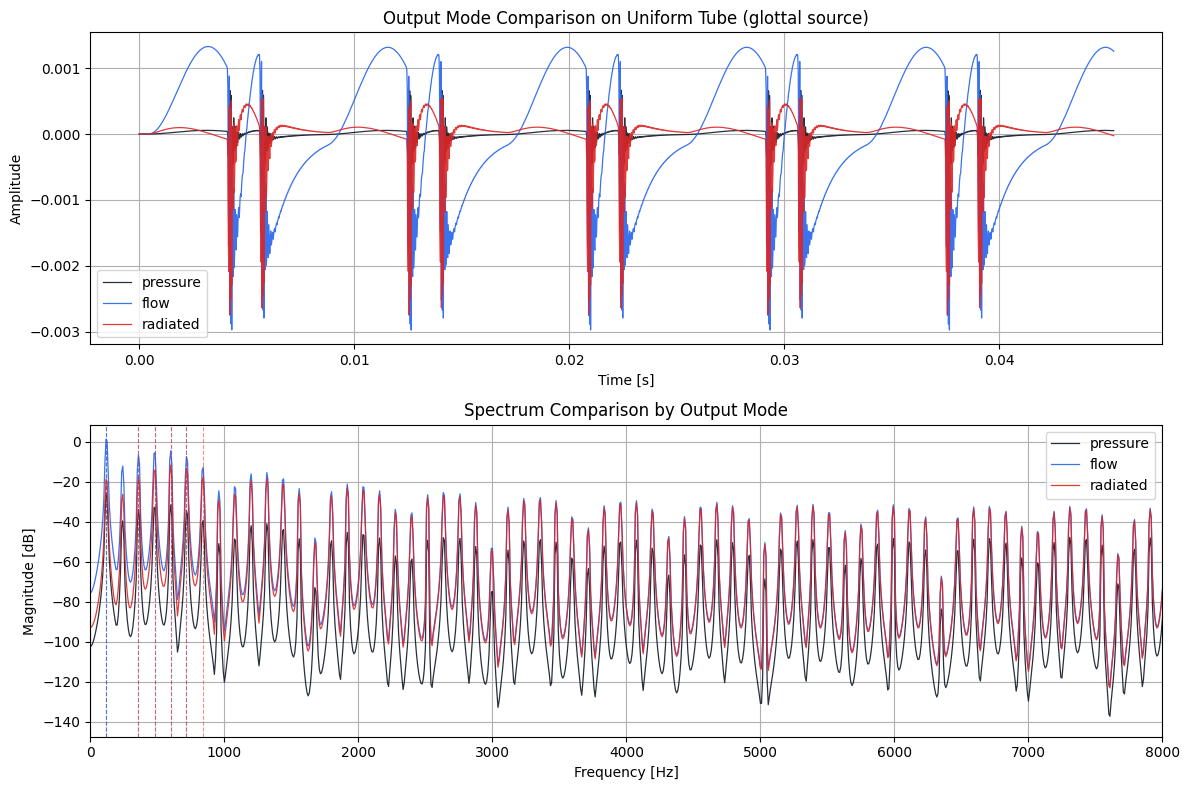

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
colors = {"pressure": "#111827", "flow": "#2563eb", "radiated": "#dc2626"}

for mode in output_modes:
    data = mode_results[mode]
    color = colors[mode]
    axes[0].plot(time_axis[:2000], data["output"][:2000], linewidth=0.9, label=mode, color=color, alpha=0.9)
    axes[1].plot(data["frequencies"], data["magnitude_db"], linewidth=0.9, label=mode, color=color, alpha=0.9)
    for peak_hz in data["peaks"]:
        axes[1].axvline(peak_hz, color=color, linestyle="--", linewidth=0.8, alpha=0.5)

axes[0].set_title("Output Mode Comparison on Uniform Tube (glottal source)")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].set_title("Spectrum Comparison by Output Mode")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude [dB]")
axes[1].set_xlim(0, 8000)
axes[1].legend()

plt.tight_layout()
plt.show()


## 観測量の比較: `vowel_a` / `vowel_i` での差

直管だけでなく、簡易母音形状でも `flow` と `radiated` が差を見せやすいかを確認します。


In [21]:
vowel_mode_compare = {}
for mode in ["flow", "radiated"]:
    vowel_mode_compare[mode] = {}
    mode_config = dict(config)
    mode_config["output_mode"] = mode
    for vowel in compare_vowels:
        shape_v = make_vowel_shape(vowel, length_m=tube_length_m)
        mesh_v = build_rect_mesh(shape_v, dx=mode_config["grid_step_m"])
        result_v = run_dwm(mesh_v, glottal_source, mode_config, probe="lip")
        output_v = result_v["output"]
        freqs_v, mag_v = compute_spectrum(output_v, sample_rate)
        peaks_v = find_major_peaks(output_v, sample_rate, n_peaks=5)
        vowel_mode_compare[mode][vowel] = {
            "output": output_v,
            "frequencies": freqs_v,
            "magnitude_db": mag_v,
            "peaks": peaks_v,
        }

{mode: {vowel: [float(v) for v in data["peaks"]] for vowel, data in mode_data.items()} for mode, mode_data in vowel_mode_compare.items()}


{'flow': {'a': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 'radiated': {'a': [483.33333333333337,
   600.0,
   716.6666666666667,
   841.6666666666667,
   1316.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]}}

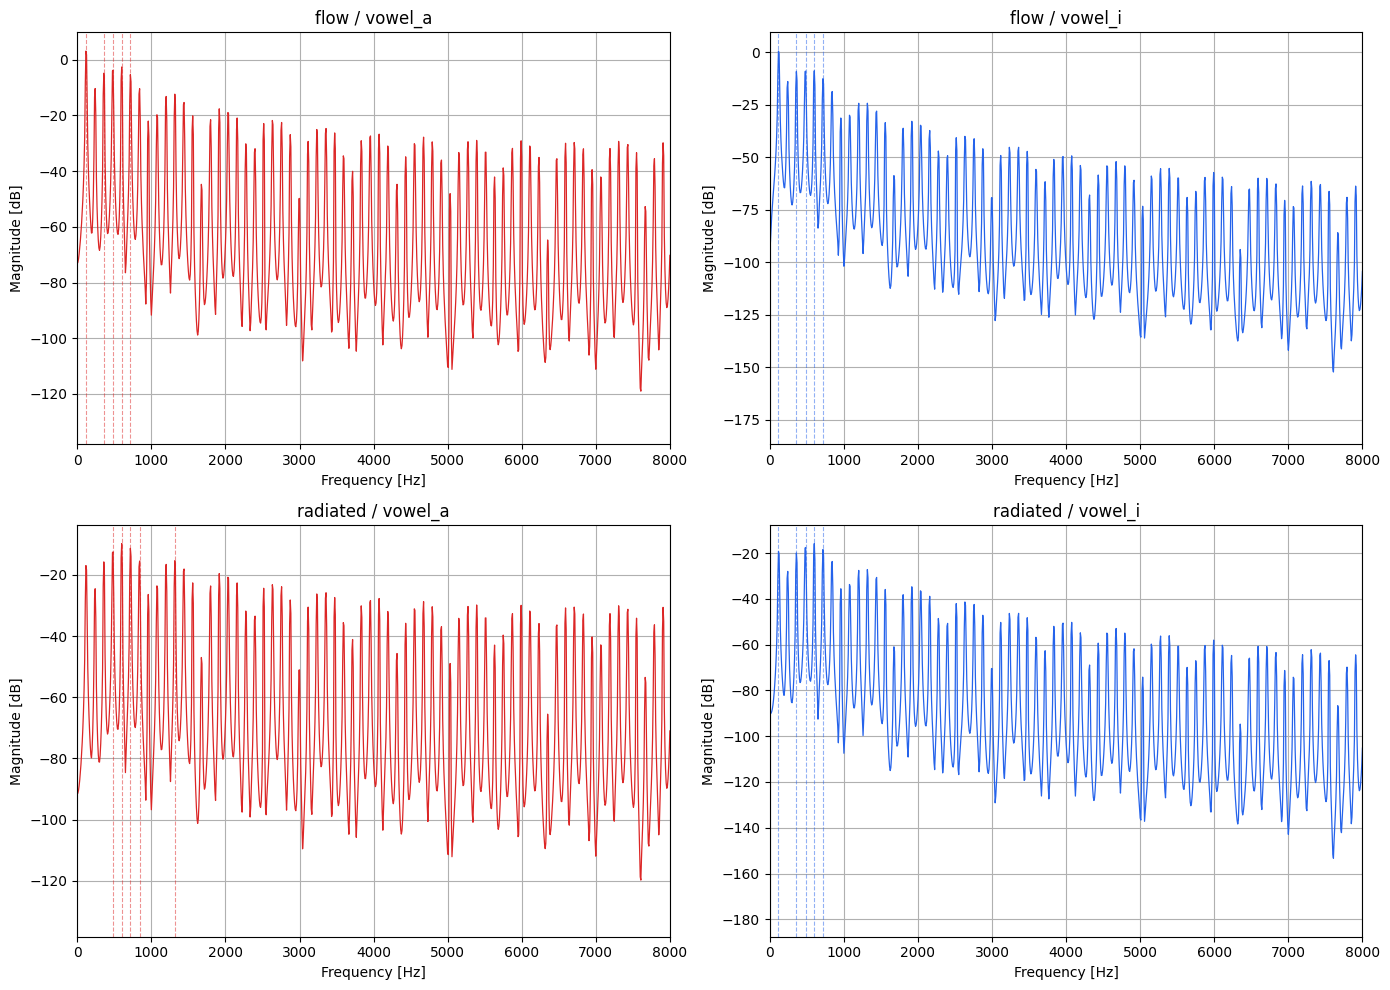

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
layout = [("flow", "a"), ("flow", "i"), ("radiated", "a"), ("radiated", "i")]
colors = {"a": "#dc2626", "i": "#2563eb"}

for ax, (mode, vowel) in zip(axes.ravel(), layout):
    data = vowel_mode_compare[mode][vowel]
    ax.plot(data["frequencies"], data["magnitude_db"], color=colors[vowel], linewidth=0.9)
    for peak_hz in data["peaks"]:
        ax.axvline(peak_hz, color=colors[vowel], linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title(f"{mode} / vowel_{vowel}")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Magnitude [dB]")
    ax.set_xlim(0, 8000)

plt.tight_layout()
plt.show()


## 暫定判断

この段階では、次の観点で主出力候補を判断します。

- 直管で過度に高域へ偏りすぎないか
- `vowel_a` / `vowel_i` の差がスペクトルに現れるか
- 将来、放射近似の改善を乗せやすいか

通常は、口端そのものの圧力よりも **`radiated` を主出力候補**、`flow` を補助観測量とするのが自然です。
ただし実際の採用は、上の図とピーク位置を見て最終判断します。


## `radiation_cutoff_hz` の掃引

`radiated` を主出力とする前提で、放射近似のカットオフ周波数を変えたときに `vowel_a` / `vowel_i` の差がどう見えるかを確認します。


In [23]:
cutoff_values = [200.0, 400.0, 800.0, 1200.0, 2000.0]
cutoff_sweep = {}

for cutoff_hz in cutoff_values:
    cutoff_sweep[cutoff_hz] = {}
    sweep_config = dict(config)
    sweep_config["output_mode"] = "radiated"
    sweep_config["radiation_cutoff_hz"] = cutoff_hz
    for vowel in compare_vowels:
        sweep_shape = make_vowel_shape(vowel, length_m=tube_length_m)
        sweep_mesh = build_rect_mesh(sweep_shape, dx=sweep_config["grid_step_m"])
        sweep_result = run_dwm(sweep_mesh, glottal_source, sweep_config, probe="lip")
        sweep_output = sweep_result["output"]
        sweep_freqs, sweep_mag_db = compute_spectrum(sweep_output, sample_rate)
        sweep_peaks = find_major_peaks(sweep_output, sample_rate, n_peaks=5)
        cutoff_sweep[cutoff_hz][vowel] = {
            "result": sweep_result,
            "output": sweep_output,
            "frequencies": sweep_freqs,
            "magnitude_db": sweep_mag_db,
            "peaks": sweep_peaks,
        }

{cutoff: {vowel: [float(v) for v in data["peaks"]] for vowel, data in vowel_data.items()} for cutoff, vowel_data in cutoff_sweep.items()}


{200.0: {'a': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 400.0: {'a': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 800.0: {'a': [358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667,
   841.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 1200.0: {'a': [483.33333333333337,
   600.0,
   716.6666666666667,
   841.6666666666667,
   1316.6666666666667],
  'i': [116.66666666666667,
   358.33333333333337,
   483.33333333333337,
   600.0,
   716.6666666666667]},
 2000.0: {'a': [483.33333333333337,
   600.0,
   716.6666666666667,
   1316.6666666666667,
   20733.333333333336]

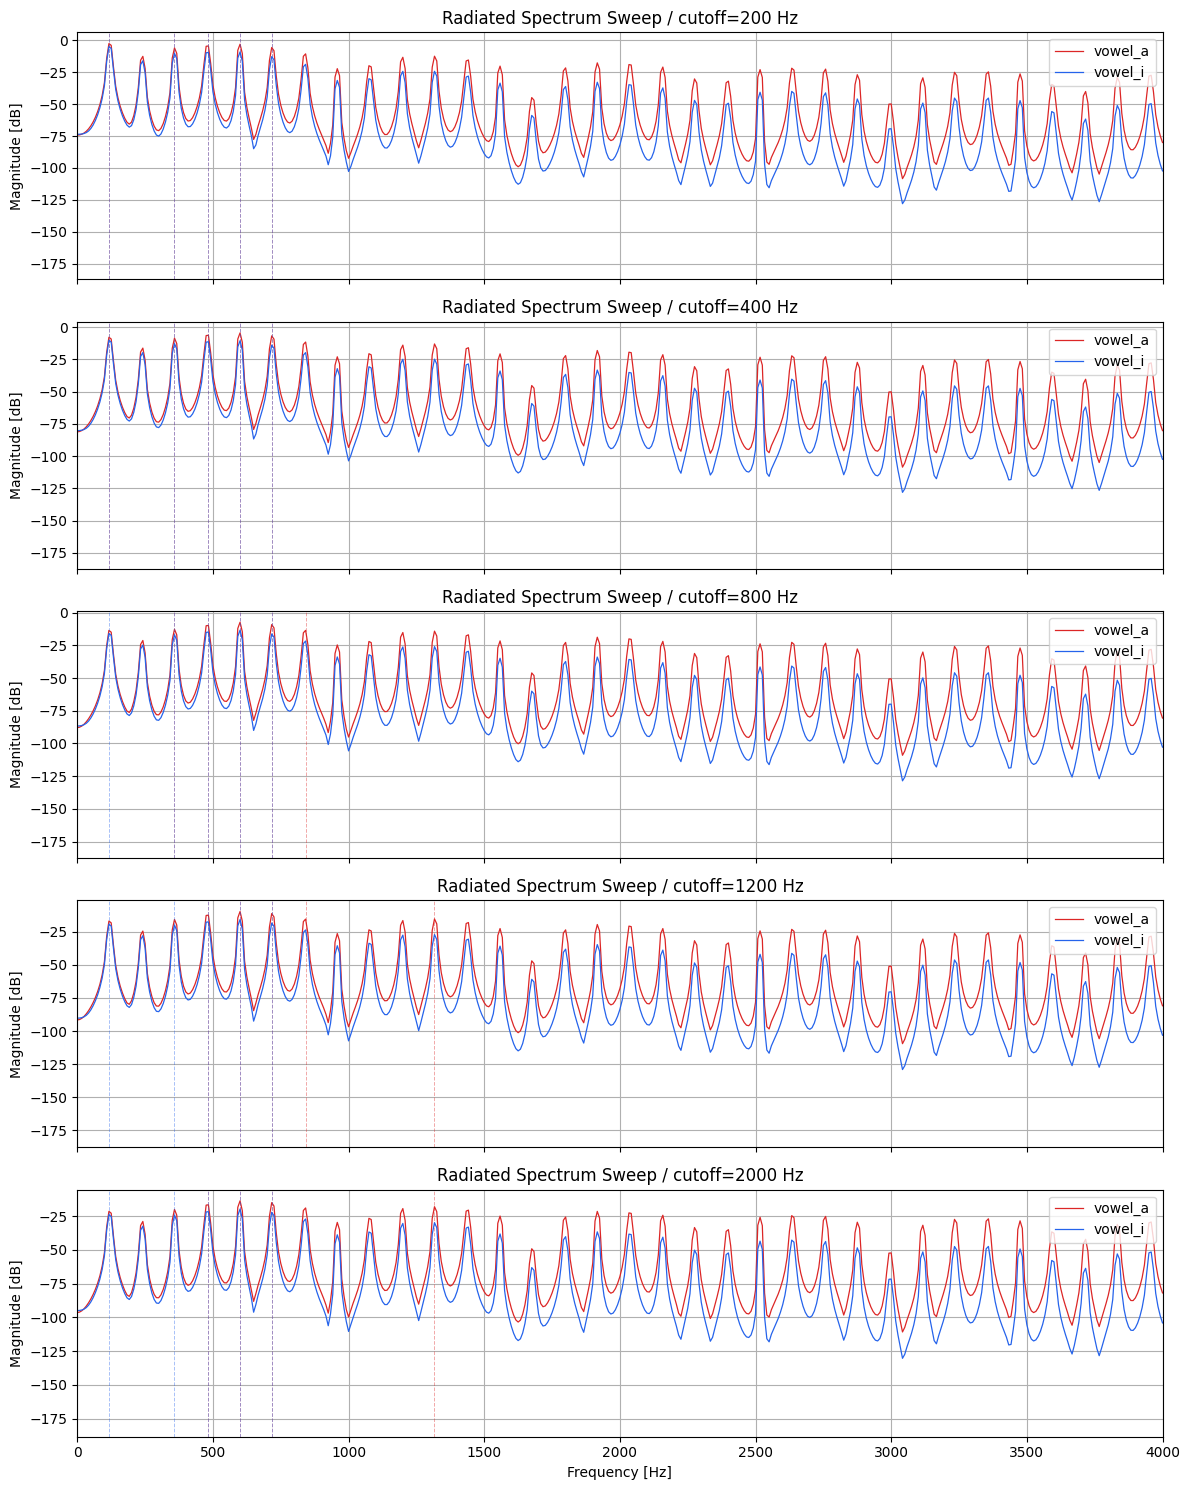

In [24]:
fig, axes = plt.subplots(len(cutoff_values), 1, figsize=(12, 3 * len(cutoff_values)), sharex=True)
if len(cutoff_values) == 1:
    axes = [axes]

colors = {"a": "#dc2626", "i": "#2563eb"}

for ax, cutoff_hz in zip(axes, cutoff_values):
    for vowel in compare_vowels:
        data = cutoff_sweep[cutoff_hz][vowel]
        ax.plot(data["frequencies"], data["magnitude_db"], color=colors[vowel], linewidth=0.9, label=f"vowel_{vowel}")
        for peak_hz in data["peaks"]:
            ax.axvline(peak_hz, color=colors[vowel], linestyle="--", linewidth=0.7, alpha=0.4)
    ax.set_title(f"Radiated Spectrum Sweep / cutoff={cutoff_hz:.0f} Hz")
    ax.set_ylabel("Magnitude [dB]")
    ax.set_xlim(0, 4000)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Frequency [Hz]")
plt.tight_layout()
plt.show()


In [25]:
cutoff_summary = []
for cutoff_hz in cutoff_values:
    peaks_a = np.asarray(cutoff_sweep[cutoff_hz]["a"]["peaks"], dtype=np.float64)
    peaks_i = np.asarray(cutoff_sweep[cutoff_hz]["i"]["peaks"], dtype=np.float64)
    first_a = float(peaks_a[0]) if peaks_a.size else None
    first_i = float(peaks_i[0]) if peaks_i.size else None
    separation = None if first_a is None or first_i is None else abs(first_a - first_i)
    cutoff_summary.append({
        "cutoff_hz": cutoff_hz,
        "first_peak_a": first_a,
        "first_peak_i": first_i,
        "first_peak_separation": separation,
    })

cutoff_summary


[{'cutoff_hz': 200.0,
  'first_peak_a': 116.66666666666667,
  'first_peak_i': 116.66666666666667,
  'first_peak_separation': 0.0},
 {'cutoff_hz': 400.0,
  'first_peak_a': 116.66666666666667,
  'first_peak_i': 116.66666666666667,
  'first_peak_separation': 0.0},
 {'cutoff_hz': 800.0,
  'first_peak_a': 358.33333333333337,
  'first_peak_i': 116.66666666666667,
  'first_peak_separation': 241.66666666666669},
 {'cutoff_hz': 1200.0,
  'first_peak_a': 483.33333333333337,
  'first_peak_i': 116.66666666666667,
  'first_peak_separation': 366.6666666666667},
 {'cutoff_hz': 2000.0,
  'first_peak_a': 483.33333333333337,
  'first_peak_i': 116.66666666666667,
  'first_peak_separation': 366.6666666666667}]

### 掃引の読み方

- `first_peak_separation` が大きいほど、最低限の `a/i` 差は見えやすいです。
- ただし、高域ノイズだけで差が出ている場合は採用しません。
- 低域に安定したピーク列が残りつつ、`a` と `i` の開始位置がずれるカットオフを優先します。


## 次の実験候補

- `shape_kind = "vowel_a"` や `"vowel_i"` に切り替える
- `source_kind = "simple_glottal"` で持続的な励振にする
- `grid_step_m` を小さくして解像度を上げる
- 1D 波動管と主要ピークを比較する
